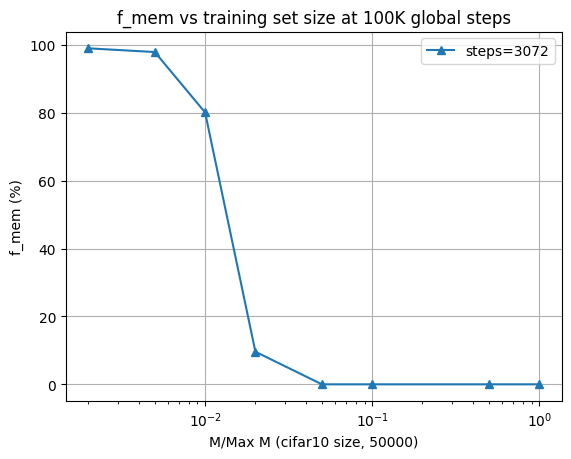

In [15]:
import matplotlib.pyplot as plt
import math

cifar10_percents = [0.002, 0.005,  0.01, 0.02, 0.05, 0.1, 0.5, 1]
# f_mem_128=[68.8, 37, 3, 0, 0, 0, 0]
# f_mem_1024=[96.1, 70.90, 9.8, 0, 0, 0, 0]
f_mem_3072=[99, 97.9, 80.1, 9.6, 0, 0, 0, 0]

# plt.plot(cifar10_percents, f_mem_128, label="steps=128", marker="^")
# plt.plot(cifar10_percents, f_mem_1024, label="steps=1024", marker="^")
plt.plot(cifar10_percents, f_mem_3072, label="steps=3072", marker="^")  
plt.xlabel("M/Max M (cifar10 size, 50000)")
plt.ylabel("f_mem (%)")
plt.title("f_mem vs training set size at 100K global steps")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.show()


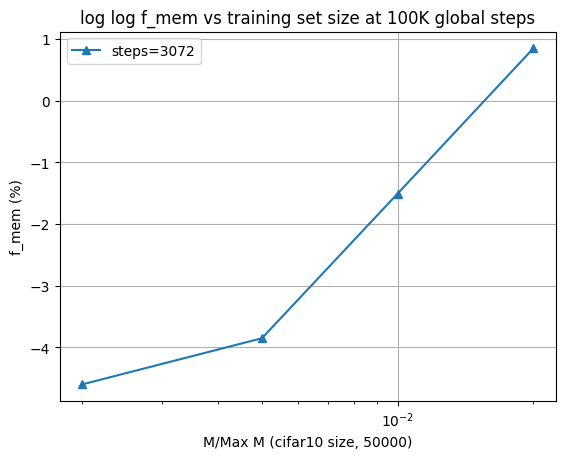

In [17]:
# cifar10_percents = [0.005, 0.01, 0.02]
# f_mem_128=[68.8, 37, 3]
# f_mem_1024=[96.1, 70.90, 9.8]
# f_mem_3072=[97.9, 80.1, 9.6]

cifar10_percents = [0.002, 0.005, 0.01, 0.02]

f_mem_3072=[99, 97.9, 80.1, 9.6]


# plt.plot(cifar10_percents, [math.log(-math.log(x/100)) for x in f_mem_128], marker="^", label="steps=128")
# plt.plot(cifar10_percents, [math.log(-math.log(x/100)) for x in f_mem_1024], marker="^", label="steps=1024")
plt.plot(cifar10_percents, [math.log(-math.log(x/100)) for x in f_mem_3072], marker="^", label="steps=3072")    
plt.xlabel("M/Max M (cifar10 size, 50000)")
plt.ylabel("f_mem (%)")
plt.title("log log f_mem vs training set size at 100K global steps")
plt.xscale("log")
plt.grid(True)
plt.legend()
plt.show()


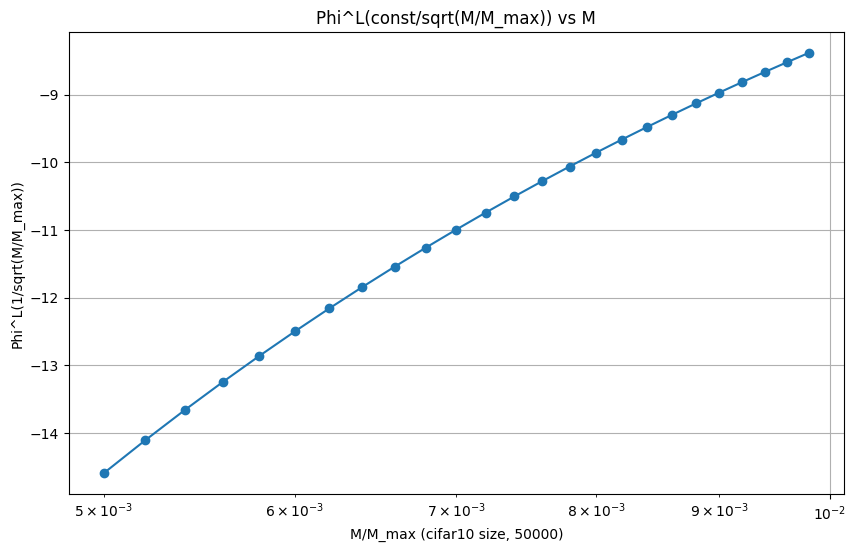

In [19]:
import math
from scipy.stats import norm

# Calculate Phi^L(const/sqrt(M/L)) where Phi is the normal CDF

L=3072
M_vals = range(250, 500, 10)

# M is the number of samples, calculate const/sqrt(M/L) for each alpha value
const_over_sqrt_m_l = [ 1.4/ math.sqrt(M/L) for M in M_vals]

# Apply Phi (normal CDF) and raise to power L
log_phi_values = [math.log(-math.log(norm.cdf(x))) for x in const_over_sqrt_m_l]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot([M/50000 for M in M_vals], log_phi_values, marker="o")
plt.xlabel("M/M_max (cifar10 size, 50000)")
plt.ylabel("Phi^L(1/sqrt(M/M_max))")
plt.title("Phi^L(const/sqrt(M/M_max)) vs M")
plt.xscale("log")
plt.grid(True)
plt.show()